In [1]:
import kagglehub
tongpython_cat_and_dog_path = kagglehub.dataset_download('tongpython/cat-and-dog')

print('Data source import complete.')


Using Colab cache for faster access to the 'cat-and-dog' dataset.
Data source import complete.


In [11]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split,  Subset
from torchvision import transforms, datasets, models
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt


for dirname, _, filenames in os.walk('/kaggle/input'):
    print(f'in folder {dirname} we have {len(filenames)} images')

in folder /kaggle/input we have 0 images
in folder /kaggle/input/cat-and-dog we have 0 images
in folder /kaggle/input/cat-and-dog/test_set we have 0 images
in folder /kaggle/input/cat-and-dog/test_set/test_set we have 0 images
in folder /kaggle/input/cat-and-dog/test_set/test_set/dogs we have 1013 images
in folder /kaggle/input/cat-and-dog/test_set/test_set/cats we have 1012 images
in folder /kaggle/input/cat-and-dog/training_set we have 0 images
in folder /kaggle/input/cat-and-dog/training_set/training_set we have 0 images
in folder /kaggle/input/cat-and-dog/training_set/training_set/dogs we have 4006 images
in folder /kaggle/input/cat-and-dog/training_set/training_set/cats we have 4001 images


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

using device: cuda


In [4]:
%ls /kaggle/input/cat-and-dog/

test_set/  training_set/


In [5]:
# Define the transforamtion (preprocessing)
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dir = '/kaggle/input/cat-and-dog/training_set/training_set'
test_dir = '/kaggle/input/cat-and-dog/test_set/test_set'

full_train_data = datasets.ImageFolder(root = train_dir, transform= transform)
test_data = datasets.ImageFolder(root= test_dir, transform= transform)

# Create a training a validation set
train_size = int(0.8 * len(full_train_data))
val_size = len(full_train_data) - train_size
train_data, val_data = random_split(full_train_data, [train_size, val_size])

# The DataLoaders (lazy workers)
train_loader = DataLoader(train_data, batch_size= 32, shuffle= True)
val_loader = DataLoader(val_data, batch_size= 32, shuffle= True)
test_loader = DataLoader(test_data, batch_size= 32, shuffle= True)

print(f'Dataset loaded: {len(train_data)} train, {len(val_data)} validation, {len(test_data)} test Images')

Dataset loaded: 6404 train, 1601 validation, 2023 test Images


In [6]:
# Create the multi-layer-perceptron calssifier class
class MLPClassifier(nn.Module):
    def __init__(self):
        super(MLPClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            #224 * 224 px * 3 colors(RGB) input size
            nn.Linear(224*224*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

model_mlp = MLPClassifier().to(device)
print(model_mlp)

MLPClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=150528, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [7]:
# Training phase
def train_and_log(model, train_loader, val_loader, epochs= 3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr= 0.001)

    stats = {
        'train_acc':[],
        'val_acc': [],
        'train_loss':[],
        'val_loss': []
    }

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct= 0,0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            t_loss+= loss.item()
            _, predicted = torch.max(outputs, 1)
            t_correct+= (predicted == labels).sum().item()
        stats['train_loss'].append(t_loss)

        # Validation
        model.eval()
        v_loss, v_correct = 0,0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, predicted= torch.max(outputs, 1)
                v_loss+= loss.item()
                v_correct+= (predicted==labels).sum().item()
        stats['val_loss'].append(v_loss)
        stats['train_acc'].append((t_correct/ len(train_loader.dataset)))
        stats['val_acc'].append((v_correct/ len(val_loader.dataset)))
        print(f'Epoch {epoch+1}: Train accuracy: {stats['train_acc'][-1]:.2f}, validation accuracy: {stats['val_acc'][-1]:.2f}')

    return stats

# Start Training thr MLP
print("Starting Training....")
mlp_results = train_and_log(model_mlp,train_loader= train_loader ,val_loader= val_loader )

Starting Training....
Epoch 1: Train accuracy: 0.56, validation accuracy: 0.60
Epoch 2: Train accuracy: 0.63, validation accuracy: 0.61
Epoch 3: Train accuracy: 0.66, validation accuracy: 0.61


#### MLP is bad


## Lets try CNN

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # 3 input channels (RGB), 16 filters
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Shrinks 224x224 to 112x112
        )
        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Shrinks 112x112 to 56x56
        )

        # Classification Block (MLP at the end)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128), # 32 channels * 56px * 56px
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.classifier(x)
        return x

model_cnn = SimpleCNN().to(device)
print("Training CNN...")
cnn_results = train_and_log(model_cnn, train_loader, val_loader, epochs=5)

Training CNN...
Epoch 1: Train accuracy: 0.58, validation accuracy: 0.63
Epoch 2: Train accuracy: 0.69, validation accuracy: 0.72
Epoch 3: Train accuracy: 0.75, validation accuracy: 0.73
Epoch 4: Train accuracy: 0.82, validation accuracy: 0.72
Epoch 5: Train accuracy: 0.89, validation accuracy: 0.70


#### That's better than MLP, with some tuning to the parameters and layers the model will produce even much better results, but this is good for now.

### Transfer Learning with all the layers frozen except the last layer(classification layer)

In [12]:
# Load pretrained ResNet18
model_tl = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# FREEZE: Tell PyTorch not to update these weights
for param in model_tl.parameters():
    param.requires_grad = False

# Replace the final layer (Fully Connected) to match our 2 classes
num_ftrs = model_tl.fc.in_features
model_tl.fc = nn.Linear(num_ftrs, 2)

model_tl = model_tl.to(device)
print("Training Transfer Learning (FC Only)...")
tl_results = train_and_log(model_tl, train_loader, val_loader, epochs=3)

Training Transfer Learning (FC Only)...
Epoch 1: Train accuracy: 0.94, validation accuracy: 0.97
Epoch 2: Train accuracy: 0.96, validation accuracy: 0.98
Epoch 3: Train accuracy: 0.96, validation accuracy: 0.97


#### using a pretrained model with only changing the last layer has saved us a lot of time if we were to train the CNNs from scrach and also resulted in a perfect accuray.

### Let's compare the filters plot before and after training

Filters BEFORE training (Random):


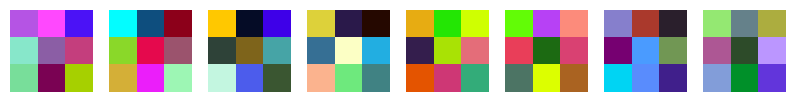

Filters AFTER training (Learned):


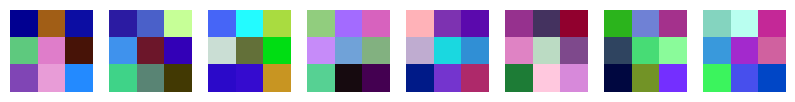

In [13]:
def plot_filters(layer):
    filters = layer.weight.data.cpu().numpy()
    plt.figure(figsize=(10, 5))
    for i in range(min(8, filters.shape[0])): # Show first 8 filters
        plt.subplot(1, 8, i+1)
        # Normalize filter values to [0, 1] for display
        f = filters[i]
        f = (f - f.min()) / (f.max() - f.min())
        plt.imshow(f.transpose(1, 2, 0))
        plt.axis('off')
    plt.show()

print("Filters BEFORE training (Random):")
# Create a fresh model to show random weights
temp_model = SimpleCNN()
plot_filters(temp_model.conv1[0])

print("Filters AFTER training (Learned):")
plot_filters(model_cnn.conv1[0])

In [14]:
model_ft = models.resnet18(pretrained=True)

# 1. Freeze everything first
for param in model_ft.parameters():
    param.requires_grad = False

# 2. Unfreeze the 'Layer 4' (The last major block of ResNet18)
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# 3. Replace and unfreeze the FC layer
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to('cuda')
# Now train using your train_and_log function!
print('Training tranfer leaning with more than one layer customized....')
model_ft_results = train_and_log(model_ft, train_loader, val_loader, epochs=3)

Training tranfer leaning with more than one layer customized....
Epoch 1: Train accuracy: 0.96, validation accuracy: 0.98
Epoch 2: Train accuracy: 0.98, validation accuracy: 0.98
Epoch 3: Train accuracy: 0.99, validation accuracy: 0.98


In [16]:
import json

all_results = {
    "MLP": mlp_results,
    "CNN": cnn_results,
    "Transfer_Learning_3A": tl_results,
    "Transfer_Learning_3B": model_ft_results
}

with open('/content/results.json', 'w') as f:
    json.dump(all_results, f)

### Here is all the results

In [17]:
for model in all_results:
    print(f'for {model} model, results are :\n{all_results[model]}\n\n')

for MLP model, results are :
{'train_acc': [0.5552779512804498, 0.6306995627732667, 0.6611492816989382], 'val_acc': [0.6046221111805122, 0.6071205496564647, 0.6108682073703935], 'train_loss': [271.8838129043579, 129.0260266661644, 123.81348603963852], 'val_loss': [34.104802548885345, 36.03717488050461, 36.172040194272995]}


for CNN model, results are :
{'train_acc': [0.584946908182386, 0.688475952529669, 0.7471892567145534, 0.8218301061836353, 0.8856964397251718], 'val_acc': [0.6264834478450968, 0.7164272329793879, 0.7257963772642099, 0.7239225484072455, 0.7039350405996252], 'train_loss': [148.37051963806152, 116.88653180003166, 100.39216989278793, 77.49159382283688, 53.010689310729504], 'val_loss': [32.68380689620972, 28.039311107248068, 28.08659851551056, 28.334727404639125, 35.95182776451111]}


for Transfer_Learning_3A model, results are :
{'train_acc': [0.9398813241723922, 0.9611180512179888, 0.9648657089319176], 'val_acc': [0.9725171767645222, 0.9762648344784509, 0.9718925671455

### Saving Models for Download

In [18]:
torch.save(model_mlp.state_dict(), '/content/mlp_classifier.pth')
torch.save(model_cnn.state_dict(), '/content/simple_cnn.pth')
torch.save(model_tl.state_dict(), '/content/transfer_learning_fc_only.pth')
torch.save(model_ft.state_dict(), '/content/transfer_learning_layer4_fc.pth')

print("All models saved successfully.")

All models saved successfully.


Now, let's create a zip file containing all the saved models and the results for easy download.

In [25]:
# The creation of the zip file for download and Google Drive is now handled in the subsequent cell.
print("Zip file creation for download is now integrated with the Google Drive save operation.")

Zip file creation for download is now integrated with the Google Drive save operation.


### Save Models and Results to Google Drive

In [28]:
from google.colab import drive
drive.mount('/content/gdrive')

# Define the destination path in Google Drive
drive_path = '/content/drive/My Drive/colab_saved_models'

# Create the directory if it doesn't exist
import os
os.makedirs(drive_path, exist_ok=True)

import shutil
import zipfile

# List of individual files to copy from /content/ to Google Drive
individual_files_to_copy = [
    'mlp_classifier.pth',
    'simple_cnn.pth',
    'transfer_learning_fc_only.pth',
    'transfer_learning_layer4_fc.pth',
    'results.json'
]

# Copy each individual file
for filename in individual_files_to_copy:
    source_path = os.path.join('/content/', filename)
    destination_path = os.path.join(drive_path, filename)
    if os.path.exists(source_path):
        shutil.copy(source_path, destination_path)
        print(f"Copied {filename} to Google Drive: {destination_path}")
    else:
        print(f"Warning: {filename} not found at {source_path} - Skipping copy.")

# --- Create and copy the zip file directly to Google Drive ---
zip_filename = 'trained_models_and_results.zip'
zip_destination_path_in_drive = os.path.join(drive_path, zip_filename)

# Ensure all individual files exist before zipping
files_to_zip_into_archive = [
    'mlp_classifier.pth',
    'simple_cnn.pth',
    'transfer_learning_fc_only.pth',
    'transfer_learning_layer4_fc.pth',
    'results.json'
]

# Filter out files that don't exist
existing_files_for_zip = [f for f in files_to_zip_into_archive if os.path.exists(os.path.join('/content/', f))]

if existing_files_for_zip:
    print(f"\nCreating zip archive '{zip_filename}' directly in Google Drive: {zip_destination_path_in_drive}")
    with zipfile.ZipFile(zip_destination_path_in_drive, 'w', zipfile.ZIP_DEFLATED) as zf:
        for file_to_add in existing_files_for_zip:
            source_file_path = os.path.join('/content/', file_to_add)
            zf.write(source_file_path, arcname=file_to_add) # arcname is the name inside the zip
    print(f"Successfully created and copied '{zip_filename}' to Google Drive.")
else:
    print("Warning: No individual files found to include in the zip archive to Google Drive.")

print("All specified files copy operation completed for Google Drive.")

Mounted at /content/gdrive


OSError: [Errno 107] Transport endpoint is not connected: '/content/drive/My Drive'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')